# 02 — Análisis Exploratorio de Datos (EDA)

Objetivos:
1. Visualizar la evolución temporal de precios por mercado.
2. Analizar la distribución de la variable objetivo (label UP/DOWN).
3. Explorar el volumen de noticias y su correlación temporal con movimientos de precio.
4. Identificar posibles problemas: desbalance de clases, datos faltantes, outliers.

In [1]:
import sys
from pathlib import Path

ROOT = Path("__file__").resolve().parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RAW_DIR = ROOT / "data" / "raw"
PROC_DIR = ROOT / "data" / "processed"
PROC_DIR.mkdir(exist_ok=True)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from src.features import build_market_features, build_labels

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 110

## 1. Cargar datos crudos

In [3]:
catalog = pd.read_csv(RAW_DIR / "markets_catalog.csv")
price_files = sorted(RAW_DIR.glob("prices_*.csv"))
news_files  = sorted(RAW_DIR.glob("news_*.csv"))

print(f"Mercados en catálogo : {len(catalog)}")
print(f"Archivos de precios  : {len(price_files)}")
print(f"Archivos de noticias : {len(news_files)}")

# Load all price series
price_dfs = {}
for f in price_files:
    slug = f.stem.replace("prices_", "")
    df = pd.read_csv(f, parse_dates=["date"])
    df["slug"] = slug
    price_dfs[slug] = df

# Load all news
news_dfs = {}
for f in news_files:
    slug = f.stem.replace("news_", "")
    df = pd.read_csv(f)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")
    news_dfs[slug] = df

print("\nMercados con datos de precios:", list(price_dfs.keys()))

Mercados en catálogo : 10
Archivos de precios  : 9
Archivos de noticias : 0

Mercados con datos de precios: ['bitboy-convicted', 'us-recession-in-2025', 'will-gta-6-cost-100', 'will-iphone-17-cost-1000-or-more', 'will-iphone-17-cost-1500-or-more', 'will-tariffs-generate-250b-in-2025', 'will-the-us-collect-between-200b-and-500b-in-revenue-in-2025', 'will-the-us-collect-between-500b-and-1t-in-revenue-in-2025', 'will-the-us-collect-less-than-100b-in-revenue-in-2025']


## 2. Series de precios

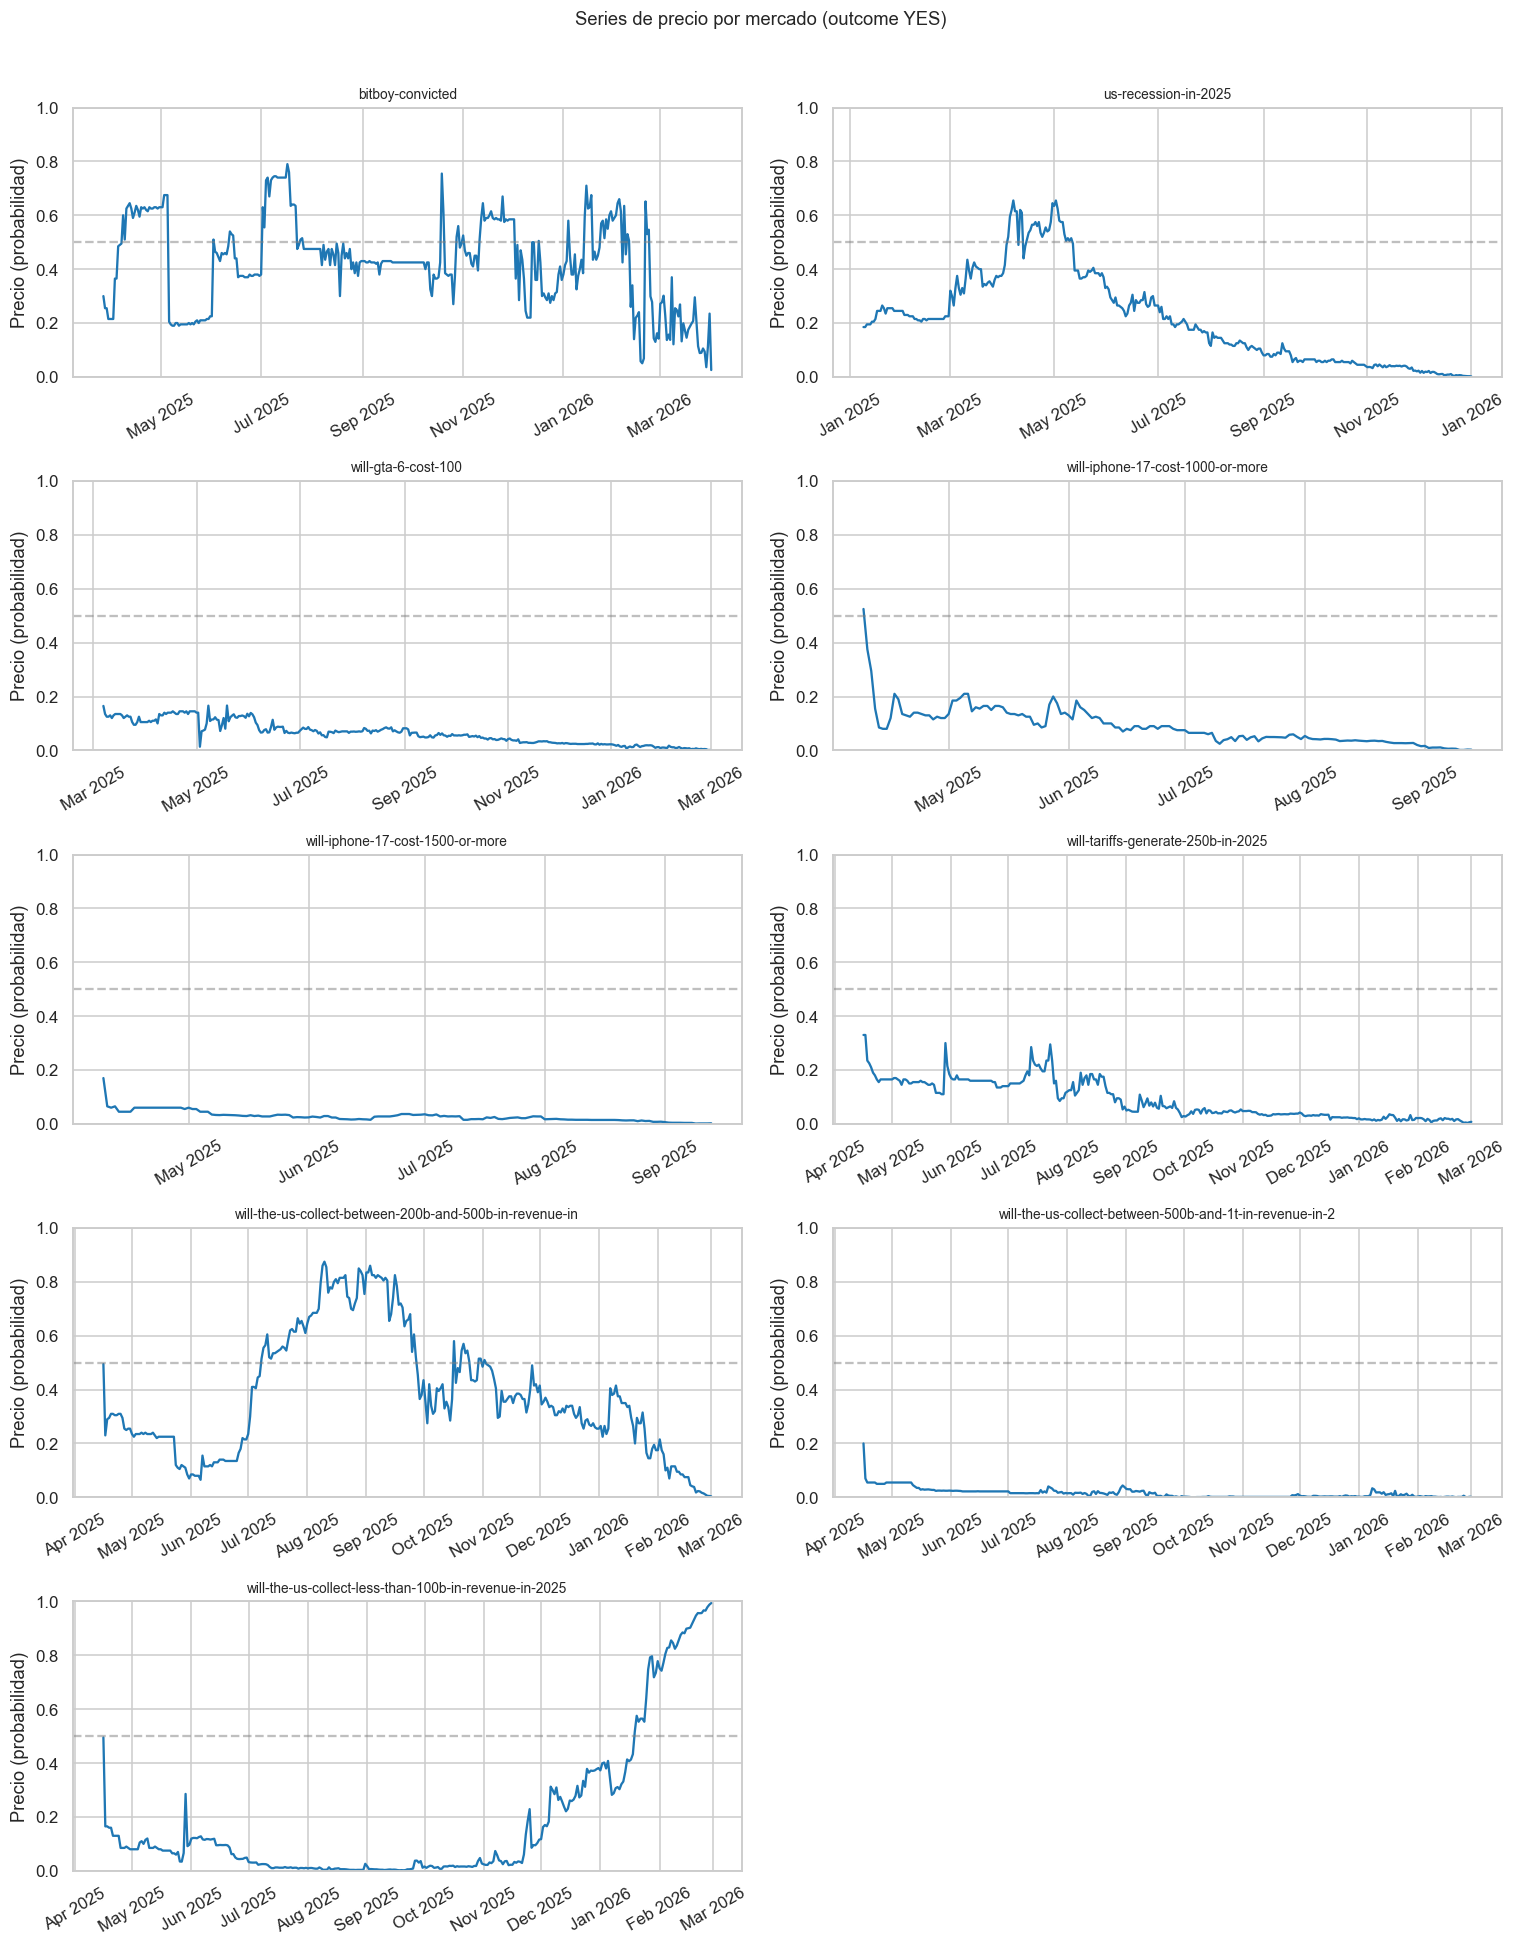

In [4]:
n = len(price_dfs)
cols = min(n, 2)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5 * rows), squeeze=False)
axes_flat = axes.flatten()

for i, (slug, df) in enumerate(price_dfs.items()):
    ax = axes_flat[i]
    ax.plot(df["date"], df["price"], linewidth=1.5)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="p=0.5")
    ax.set_title(slug[:55], fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Precio (probabilidad)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.tick_params(axis="x", rotation=30)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Series de precio por mercado (outcome YES)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(PROC_DIR / "price_series.png", bbox_inches="tight")
plt.show()

## 3. Estadísticas descriptivas de precios

In [5]:
stats = []
for slug, df in price_dfs.items():
    stats.append({
        "mercado"    : slug[:45],
        "n_días"     : len(df),
        "precio_min" : round(df["price"].min(), 3),
        "precio_max" : round(df["price"].max(), 3),
        "precio_mean": round(df["price"].mean(), 3),
        "precio_std" : round(df["price"].std(), 3),
        "inicio"     : df["date"].min().date() if hasattr(df["date"].min(), "date") else str(df["date"].min()),
        "fin"        : df["date"].max().date() if hasattr(df["date"].max(), "date") else str(df["date"].max()),
    })

pd.DataFrame(stats)

,mercado,n_días,precio_min,precio_max,precio_mean,precio_std,inicio,fin
0,bitboy-convicted,369,0.026,0.790,0.426,0.163,2025-03-27,2026-04-01
1,us-recession-in-2025,358,0.002,0.655,0.214,0.169,2025-01-09,2026-01-01
2,will-gta-6-cost-100,360,0.000,0.166,0.064,0.042,2025-03-07,2026-03-01
3,will-iphone-17-cost-1000-or-more,158,0.002,0.525,0.089,0.070,2025-04-09,2025-09-13
4,will-iphone-17-cost-1500-or-more,158,0.001,0.170,0.028,0.020,2025-04-09,2025-09-13
5,will-tariffs-generate-250b-in-2025,320,0.004,0.330,0.089,0.071,2025-04-16,2026-03-01
6,will-the-us-collect-between-200b-and-500b-in-,320,0.004,0.875,0.381,0.228,2025-04-16,2026-03-01
7,will-the-us-collect-between-500b-and-1t-in-re,320,0.000,0.200,0.016,0.018,2025-04-16,2026-03-01
8,will-the-us-collect-less-than-100b-in-revenue,315,0.002,0.994,0.178,0.258,2025-04-16,2026-02-28


## 4. Distribución de la variable objetivo (label)

,mercado,total,UP (1),DOWN (0),% UP
0,bitboy-convicted,369,146,223,39.6
1,us-recession-in-2025,358,120,238,33.5
2,will-gta-6-cost-100,360,150,210,41.7
3,will-iphone-17-cost-1000-or-more,158,50,108,31.6
4,will-iphone-17-cost-1500-or-more,158,46,112,29.1
5,will-tariffs-generate-250b-in-2025,320,110,210,34.4
6,will-the-us-collect-between-200b-and-500b-in-,320,121,199,37.8
7,will-the-us-collect-between-500b-and-1t-in-re,320,82,238,25.6
8,will-the-us-collect-less-than-100b-in-revenue,315,141,174,44.8


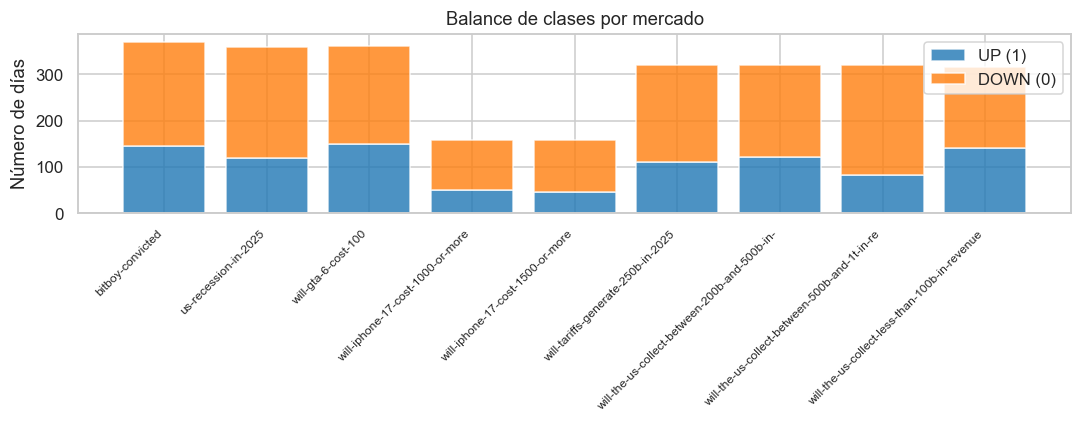

In [6]:
label_stats = []
for slug, df in price_dfs.items():
    df_feat = build_market_features(df)
    df_lab  = build_labels(df_feat).dropna(subset=["label"])
    n_total = len(df_lab)
    n_up    = int(df_lab["label"].sum())
    n_down  = n_total - n_up
    label_stats.append({
        "mercado" : slug[:45],
        "total"   : n_total,
        "UP (1)"  : n_up,
        "DOWN (0)": n_down,
        "% UP"    : round(100 * n_up / n_total, 1) if n_total else 0,
    })

label_df = pd.DataFrame(label_stats)
display(label_df)

# Barplot
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(label_df))
ax.bar(x, label_df["UP (1)"],   label="UP (1)",   alpha=0.8)
ax.bar(x, label_df["DOWN (0)"], label="DOWN (0)", alpha=0.8, bottom=label_df["UP (1)"])
ax.set_xticks(list(x))
ax.set_xticklabels(label_df["mercado"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Número de días")
ax.set_title("Balance de clases por mercado")
ax.legend()
plt.tight_layout()
plt.savefig(PROC_DIR / "label_distribution.png", bbox_inches="tight")
plt.show()

## 5. Volumen de noticias y correlación con movimientos de precio

In [7]:
# Pick the market with the most news articles for the detailed analysis
slug_for_detail = max(news_dfs, key=lambda s: len(news_dfs[s])) if news_dfs else None

if slug_for_detail and slug_for_detail in price_dfs:
    prices = price_dfs[slug_for_detail].copy()
    prices["date"] = pd.to_datetime(prices["date"], utc=True)
    news   = news_dfs[slug_for_detail].copy()

    # Daily article count
    if "date" in news.columns:
        news["date"] = pd.to_datetime(news["date"], utc=True).dt.normalize()
        daily_news = news.groupby("date").agg(
            article_count=("title" if "title" in news.columns else news.columns[0], "count"),
            mean_tone=("tone", "mean") if "tone" in news.columns else (news.columns[0], "count"),
        ).reset_index()

        merged = prices.merge(daily_news, on="date", how="left").fillna(0)

        fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

        axes[0].plot(merged["date"], merged["price"], color="steelblue")
        axes[0].set_ylabel("Precio")
        axes[0].set_title(f"Precio — {slug_for_detail[:60]}")

        for ax in axes:
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
            ax.tick_params(axis="x", rotation=30)

        plt.tight_layout()
        plt.savefig(PROC_DIR / f"news_price_alignment_{slug_for_detail}.png", bbox_inches="tight")
        plt.show()
    else:
        print("Las noticias no tienen columna 'date'")
else:
    print("Sin datos de noticias para graficar. Ejecuta el notebook 01 primero.")

Sin datos de noticias para graficar. Ejecuta el notebook 01 primero.


## 6. Distribución de retornos

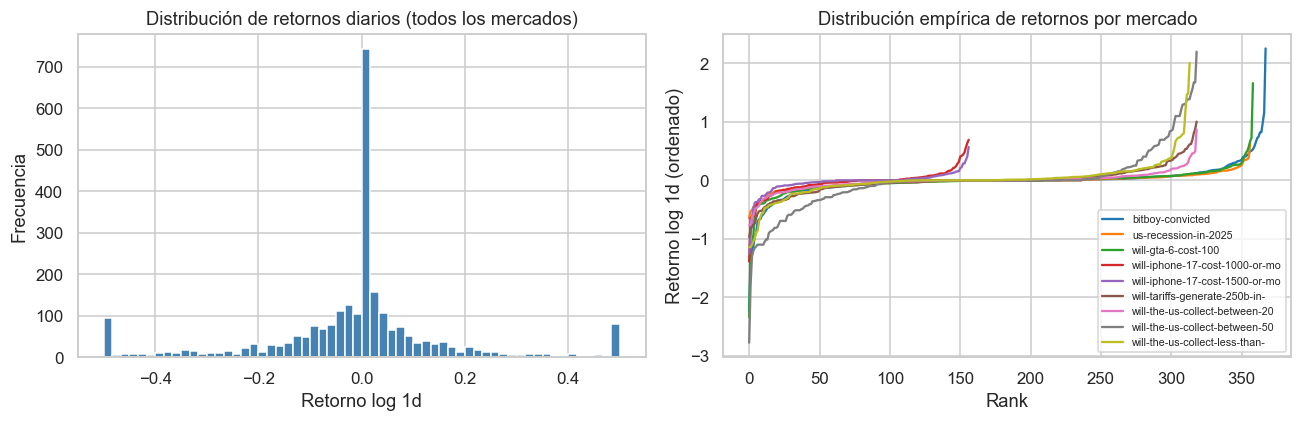

In [8]:
all_returns = []
for slug, df in price_dfs.items():
    df_feat = build_market_features(df)
    df_feat["slug"] = slug
    all_returns.append(df_feat[["slug", "ret_1d"]].dropna())

if all_returns:
    ret_df = pd.concat(all_returns, ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(ret_df["ret_1d"].clip(-0.5, 0.5), bins=60, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Retorno log 1d")
    axes[0].set_ylabel("Frecuencia")
    axes[0].set_title("Distribución de retornos diarios (todos los mercados)")

    for slug in ret_df["slug"].unique():
        subset = ret_df[ret_df["slug"] == slug]["ret_1d"].dropna()
        axes[1].plot(sorted(subset.values), label=slug[:30])
    axes[1].set_xlabel("Rank")
    axes[1].set_ylabel("Retorno log 1d (ordenado)")
    axes[1].set_title("Distribución empírica de retornos por mercado")
    axes[1].legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(PROC_DIR / "return_distributions.png", bbox_inches="tight")
    plt.show()